<a href="https://colab.research.google.com/github/Sandhan-06/fake-news-detection/blob/main/cnn_bilstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy scikit-learn tensorflow

import pandas as pd
import numpy as np
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Conv1D, MaxPooling1D, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/WELFake_Dataset (1) (1).csv')  # update path

df['content'] = df['title'] + " " + df['text']
df = df[['content', 'label']].dropna()

print(df.shape)
df.head()

(71537, 2)


,content,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",0
4,SATAN 2: Russia unvelis an image of its terrif...,1
5,About Time! Christian Group Sues Amazon and SP...,1


In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

df['content'] = df['content'].apply(clean_text)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df['content'], df['label'], test_size=0.2, random_state=42
)

In [ ]:
MAX_WORDS = 50000
MAX_LEN = 300

tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN)
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN)

word_index = tokenizer.word_index

In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

--2026-05-13 17:51:52--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-05-13 17:51:52--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-05-13 17:51:52--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [ ]:
EMBEDDING_DIM = 100

embeddings_index = {}
with open('glove.6B.100d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = vector

In [ ]:
embedding_matrix = np.zeros((MAX_WORDS, EMBEDDING_DIM))

for word, i in word_index.items():
    if i < MAX_WORDS:
        vector = embeddings_index.get(word)
        if vector is not None:
            embedding_matrix[i] = vector

In [ ]:
from tensorflow.keras.metrics import Precision, Recall

input_layer = Input(shape=(MAX_LEN,))

embedding = Embedding(
    input_dim=MAX_WORDS,
    output_dim=EMBEDDING_DIM,
    weights=[embedding_matrix],
    input_length=MAX_LEN,
    trainable=False
)(input_layer)

conv = Conv1D(filters=128, kernel_size=5, activation='relu')(embedding)
pool = MaxPooling1D(pool_size=2)(conv)

bilstm = Bidirectional(LSTM(64))(pool)

dense = Dense(64, activation='relu')(bilstm)
drop = Dropout(0.5)(dense)

output = Dense(1, activation='sigmoid')(drop)

model = Model(inputs=input_layer, outputs=output)

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 300, 100)       │     5,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 296, 128)       │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 148, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,171,265 (19.73 MB)

 Trainable params: 171,265 (669.00 KB)

 Non-trainable params: 5,000,000 (19.07 MB)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=5,          # keep small first (you can increase later)
    batch_size=64,     # safer for Colab memory
    callbacks=[early_stop]
)

Epoch 1/5
805/805 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step - accuracy: 0.8754 - loss: 0.2948 - precision: 0.8830 - recall: 0.8713 - val_accuracy: 0.9238 - val_loss: 0.1863 - val_precision: 0.9441 - val_recall: 0.9081
Epoch 2/5
805/805 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.9439 - loss: 0.1486 - precision: 0.9453 - recall: 0.9448 - val_accuracy: 0.9483 - val_loss: 0.1278 - val_precision: 0.9429 - val_recall: 0.9592
Epoch 3/5
805/805 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.9641 - loss: 0.0983 - precision: 0.9654 - recall: 0.9642 - val_accuracy: 0.9565 - val_loss: 0.1148 - val_precision: 0.9570 - val_recall: 0.9599
Epoch 4/5
805/805 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.9732 - loss: 0.0711 - precision: 0.9737 - recall: 0.9738 - val_accuracy: 0.9422 - val_loss: 0.1610 - val_precision: 0.9159 - val_recall: 0.9793
Epoch 5/5
805/805 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.9813 - loss: 0.0520 - precision: 0.9817 - recall: 0.9816 - val_accuracy: 0.9582 - val_los

In [ ]:
y_train_pred = (model.predict(X_train_pad) > 0.5).astype("int32")
y_test_pred = (model.predict(X_test_pad) > 0.5).astype("int32")

1789/1789 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step
448/448 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


In [ ]:
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

train_error = 1 - train_acc
test_error = 1 - test_acc

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

print("Train Error:", train_error)
print("Test Error:", test_error)

Train Accuracy: 0.9791713991158328
Test Accuracy: 0.9553396701146212
Train Error: 0.02082860088416716
Test Error: 0.044660329885378824


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

Precision: 0.9537190082644628
Recall: 0.9580738895807389
F1-score: 0.9558914889211017

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.95      0.95      7081
           1       0.95      0.96      0.96      7227

    accuracy                           0.96     14308
   macro avg       0.96      0.96      0.96     14308
weighted avg       0.96      0.96      0.96     14308



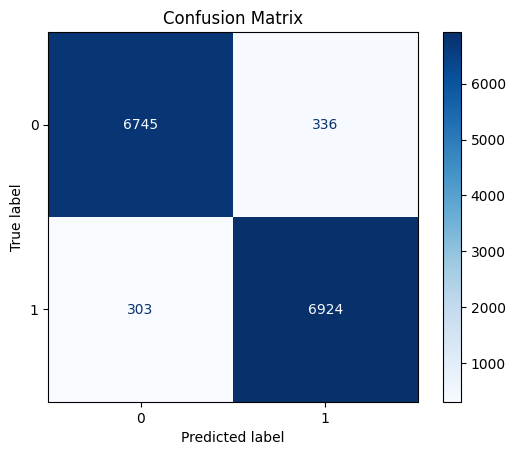

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

448/448 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step


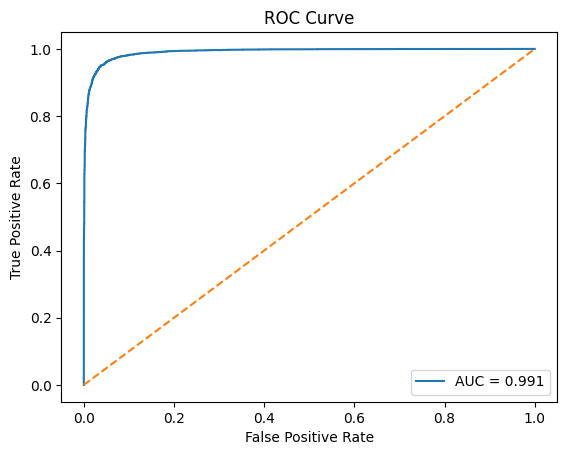

In [ ]:
from sklearn.metrics import roc_curve, auc

# Use probabilities (not binary predictions)
y_probs = model.predict(X_test_pad)

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=21a89440e89fc96f608396e76d9e302222612b1a1b11b8de506c172ad31397b2
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import numpy as np
from lime.lime_text import LimeTextExplainer

In [ ]:
class_names = ['Real', 'Fake']  # 0 = Real, 1 = Fake

explainer = LimeTextExplainer(class_names=class_names)

In [ ]:
def predict_proba(texts):
    # Convert text → sequence
    seq = tokenizer.texts_to_sequences(texts)

    # Pad sequences
    padded = pad_sequences(seq, maxlen=MAX_LEN)

    # Get model predictions (probabilities)
    probs = model.predict(padded)

    # Convert to 2-class format [Real, Fake]
    probs = np.hstack([1 - probs, probs])

    return probs

In [ ]:
idx = 10  # you can change this

sample_text = X_test.iloc[idx]
print(sample_text[:500])  # preview first 500 chars

trump heads to white house after stunning win clinton … november   trump heads to white house after stunning win clinton … 
republican donald trump stunned the world by defeating heavily favored rival hillary clinton in the us presidential election ending eight years of democratic control of the white house and sending america on a new uncertain path 
a wealthy real estate developer and former reality tv host trump rode a wave of anger toward washington insiders to win tuesday’s white house race


In [ ]:
exp = explainer.explain_instance(
    sample_text,
    predict_proba,
    num_features=10
)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [ ]:
from IPython.display import HTML

HTML('''
<style>
.lime { background-color: white !important; color: black !important; }
</style>
''')

In [ ]:
exp.save_to_file("lime.html")

In [ ]:
from IPython.core.display import display, HTML

display(HTML("""
<style>
body {
    background-color: white !important;
    color: black !important;
}

.lime {
    background-color: white !important;
    color: black !important;
}
</style>
"""))

exp.show_in_notebook(text=True)

In [ ]:
exp.save_to_file('lime_explanation.html')

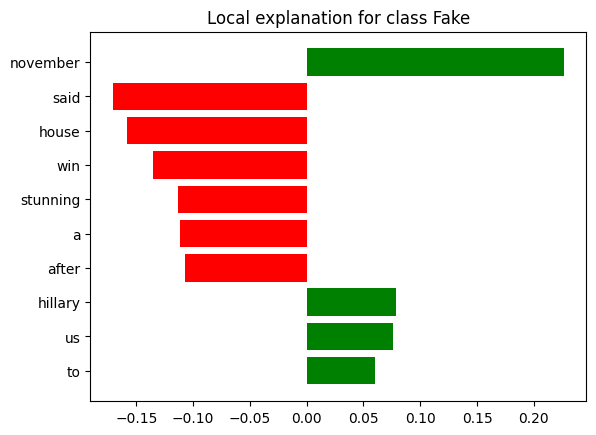

In [ ]:
fig = exp.as_pyplot_figure()

fig.savefig(
    "lime_plot.png",
    dpi=300,
    bbox_inches='tight'
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 368ms/step


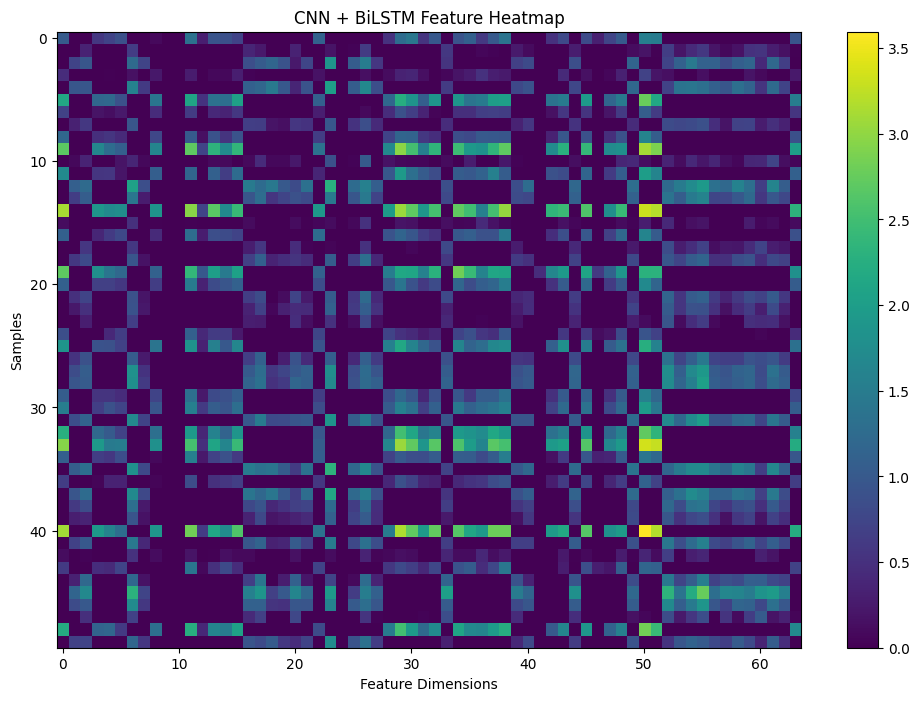

In [ ]:
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

# Extract intermediate features
feature_model = Model(
    inputs=model.input,
    outputs=model.get_layer(index=-3).output
)

features = feature_model.predict(X_test_pad[:50])

plt.figure(figsize=(12,8))

plt.imshow(features, aspect='auto')

plt.colorbar()

plt.title("CNN + BiLSTM Feature Heatmap")

plt.xlabel("Feature Dimensions")
plt.ylabel("Samples")

plt.show()

In [ ]:
print(exp.as_list())

[(np.str_('november'), 0.22641490609361686), (np.str_('said'), -0.17058048322582484), (np.str_('house'), -0.15829224580276033), (np.str_('win'), -0.13523705204883657), (np.str_('stunning'), -0.11363042433222037), (np.str_('a'), -0.11133791225671395), (np.str_('after'), -0.10698490553653414), (np.str_('hillary'), 0.0782699555692221), (np.str_('us'), 0.07615034318349795), (np.str_('to'), 0.060449132201050526)]


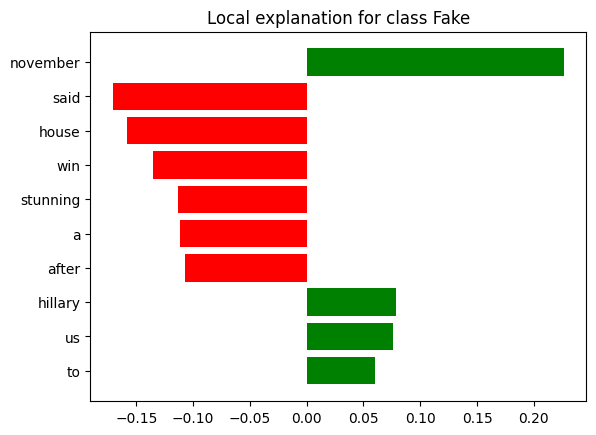

In [ ]:
fig = exp.as_pyplot_figure()

448/448 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step
(14308, 64)


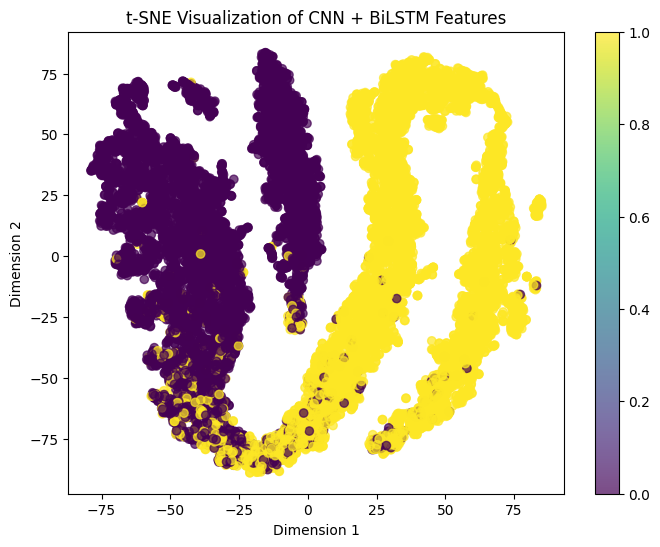

In [ ]:
from tensorflow.keras.models import Model
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Extract features from Dense layer
feature_model = Model(
    inputs=model.input,
    outputs=model.get_layer(index=-3).output
)

features = feature_model.predict(X_test_pad)

print(features.shape)

# Apply t-SNE
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(features)

# Plot
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=y_test,
    alpha=0.7
)

plt.title("t-SNE Visualization of CNN + BiLSTM Features")

plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.colorbar(scatter)

plt.show()